# Importações

In [2]:
import numpy as np
import sklearn as sk
import seaborn as sb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.stats import zscore

In [3]:
house = pd.read_csv("data.csv")
house2 = house.filter(['price', 'bedrooms'], axis=1)

In [4]:
house2.head()

,price,bedrooms
0,313000.0,3.0
1,2384000.0,5.0
2,342000.0,3.0
3,420000.0,3.0
4,550000.0,4.0


In [5]:
house2.tail()

,price,bedrooms
4595,308166.666667,3.0
4596,534333.333333,3.0
4597,416904.166667,3.0
4598,203400.000000,4.0
4599,220600.000000,3.0


In [6]:
house2.describe()

,price,bedrooms
count,4.600000e+03,4600.000000
mean,5.519630e+05,3.400870
std,5.638347e+05,0.908848
min,0.000000e+00,0.000000
25%,3.228750e+05,3.000000
50%,4.609435e+05,3.000000
75%,6.549625e+05,4.000000
max,2.659000e+07,9.000000


In [7]:
house2.isnull().sum()

price       0
bedrooms    0
dtype: int64

In [8]:
selected_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']
count_multiple = (house[selected_cols] < 0).sum().sum()
print(f"Total negative count in columns: {count_multiple}")

Total negative count in columns: 0


In [9]:
selected_cols = ['price', 'bedrooms']
count_multiple = (house[selected_cols] < 0).sum().sum()
print(f"Total negative count in columns: {count_multiple}")

Total negative count in columns: 0


# Cleaning data with one feature

In [10]:
# Z-Score

house2[["price", "bedrooms"]] = house2[["price", "bedrooms"]].apply(zscore)
print(house2)

         price  bedrooms
0    -0.423864 -0.441122
1     3.249598  1.759705
2    -0.372424 -0.441122
3    -0.234071 -0.441122
4    -0.003482  0.659291
...        ...       ...
4595 -0.432437 -0.441122
4596 -0.031271 -0.441122
4597 -0.239562 -0.441122
4598 -0.618268  0.659291
4599 -0.587759 -0.441122

[4600 rows x 2 columns]


In [11]:
x = house2['bedrooms']
y = house2['price']
alpha = 0.01
N = 10000
m = len(house2['price'])


w = 0
b = 0
cost_history = []
w_history = []
b_history = []

for iter in range(N):
    sum_squared_error = 0
    sum_error_times_x = 0
    sum_error = 0

    for i in range(m):
        prediction = w * x[i] + b
        error = prediction - y[i]

        sum_squared_error = sum_squared_error + error ** 2
        sum_error_times_x = sum_error_times_x + error * x[i]
        sum_error = sum_error + error

    J = (1 / (2 * m)) * sum_squared_error
    cost_history.append(J)
    

    dj_dw = (1 / m) * sum_error_times_x
    dj_db = (1 / m) * sum_error

    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    w_history.append(w)
    b_history.append(b)

    print(J, w, b)

0.5000000000000002 0.0020033628937567603 6.736157525497418e-19
0.49960066044303336 0.003986692158575958 1.3945366600617729e-18
0.49920926774325175 0.00595018813074695 1.9440970572512253e-18
0.49882566375819415 0.007894049143196247 2.3541555178682125e-18
0.4984496934924412 0.009818471545521044 2.928575256696011e-18
0.4980812050349757 0.011723649723822597 3.2872255642162247e-18
0.4977200494978122 0.013609776120341128 3.924638392049929e-18
0.49736608095584023 0.01547704125289448 4.322387858263464e-18
0.4970191563878506 0.017325633734122294 4.679107343132155e-18
0.4966791356187698 0.019155740290537827 5.3812027297918466e-18
0.49634588126298923 0.020967545781389218 5.943554827047632e-18
0.4960192586688871 0.02276123321733208 6.561176722703236e-18
0.4956991358644138 0.02453698377891552 6.846214416634173e-18
0.49538538350374606 0.026294976834883126 7.58282325818982e-18
0.49507787481505255 0.02803538996029106 8.49537831386541e-18
0.49477648554926823 0.02975839895444491 8.971808803128466e-18
0.

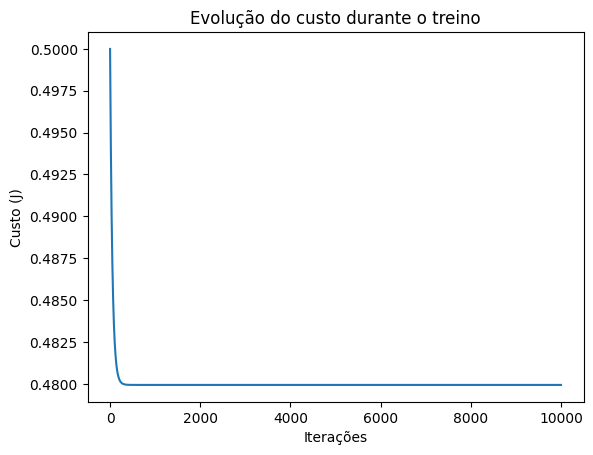

In [12]:
plt.plot(cost_history)
plt.xlabel("Iterações")
plt.ylabel("Custo (J)")
plt.title("Evolução do custo durante o treino")
plt.show()

# Training with one feature